# Mini Project: COVID-19 Detection from Chest X-rays using CNN

### Objective
A healthcare startup aims to accelerate and improve COVID-19 diagnosis using deep learning technologies. The current testing procedures are time-consuming and rely heavily on manual radiological examination, which limits scalability in pandemic situations.

As a data scientist, your task is to build a Convolutional Neural Network (CNN) model that can automatically detect COVID-19 from chest X-ray images. This solution can help hospitals:
- Reduce diagnosis time.
- Minimize burden on radiologists.
- Scale testing across regions with limited radiological expertise.

This project allows you to apply deep learning concepts, understand how CNNs process image data, and build real-world applications that can assist the medical community.

### Dataset Details
The dataset is located in the local directory under `Covid19-dataset/`. It has been divided into `train` and `test` subdirectories, each containing folders representing the three classes:
- **Covid**: Confirmed COVID-19 infection.
- **Normal**: No visible lung abnormality.
- **Viral Pneumonia**: Non-COVID lung infection.


### Tasks Overview
1. **Data Loading and Exploration**
2. **Data Preprocessing**
3. **Exploratory Data Analysis (EDA)**
4. **CNN Model Building** (Basic CNN, Transfer Learning, and Transfer Learning + Data Augmentation)
5. **Model Evaluation**
6. **Handle Class Imbalance**
7. **Model Tuning (Keras Tuner & Callbacks)**
8. **Model Comparison Table**
9. **Build a Streamlit Web App**


## Task 1. Data Loading and Exploration
a. Import necessary libraries (pandas, numpy, matplotlib, seaborn, tensorflow, keras, cv2, sklearn, etc.)


In [1]:
# ─────────────────────────────────────────────
# Standard libraries
# ─────────────────────────────────────────────
import os
import zipfile
import random
import shutil
import pickle

# ─────────────────────────────────────────────
# Data handling and math
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ─────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────
# Image Processing
# ─────────────────────────────────────────────
import cv2
from PIL import Image

# ─────────────────────────────────────────────
# Deep Learning & ML models
# ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.prenormalize_pixelsing.image import ImageDataGenerator, load_img, img_to_array

# Pre-trained Models
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import prenormalize_pixels_input as resnet_prenormalize_pixels

# Keras Tuner
import keras_tuner as kt
from keras_tuner import RandomSearch

# Metrics for evaluation
from sklearn.model_selection import train_test_split
from sklearn.prenormalize_pixelsing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)


b. Kaggle API Setup & Dataset Extraction Status
The dataset is already extracted and available locally at `Covid19-dataset/`. Below is the documentation of its location.


In [2]:
# ─────────────────────────────────────────────
# Set paths for train/test data
# ─────────────────────────────────────────────
train_dir = 'Covid19-dataset/train'
test_dir = 'Covid19-dataset/test'

print(f"Training directory: {train_dir} (Exists: {os.path.exists(train_dir)})")
print(f"Testing directory: {test_dir} (Exists: {os.path.exists(test_dir)})")


Training directory: Covid19-dataset/train (Exists: True)
Testing directory: Covid19-dataset/test (Exists: True)


c. Load images from folders, resize them to a fixed shape (150x150) and setup datasets.


In [17]:
# ─────────────────────────────────────────────
# Load dataset from folders
# ─────────────────────────────────────────────
# Set image dimensions and batch size 
image_size = (150, 150)
batch_size = 32

# Load training images
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels='inferred',
    label_mode='int',  # 'int' yields integer labels (0, 1, 2)
    batch_size=batch_size,
    image_size=image_size
)

# Load test images
validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=image_size
)


Found 251 files belonging to 3 classes.


Found 66 files belonging to 3 classes.


d. Print dataset size per class and class distribution.

Based on folder scans, the distribution of images is as follows:

| Class | Train Set Count | Test Set Count | Total |
| :--- | :---: | :---: | :---: |
| **Covid** | 111 | 26 | 137 |
| **Normal** | 70 | 20 | 90 |
| **Viral Pneumonia** | 70 | 20 | 90 |
| **Total** | **251** | **66** | **317** |


In [18]:
# ─────────────────────────────────────────────
# Print number of images in each class
# ─────────────────────────────────────────────
def print_class_counts(directory_path, split_name):
    print(f"--- {split_name.upper()} Class Distribution ---")
    total = 0
    for category in sorted(os.listdir(directory_path)):
        category_path = os.path.join(directory_path, category)
        if os.path.isdir(category_path):
            count = len([f for f in os.listdir(category_path) if not f.startswith('.')])
            total += count
            print(f"Class: {category:20} | Count: {count}")
    print(f"Total images in {split_name}: {total}\n")

print_class_counts(train_dir, 'train')
print_class_counts(test_dir, 'test')


--- TRAIN Class Distribution ---
Class: Covid                | Count: 111
Class: Normal               | Count: 70
Class: Viral Pneumonia      | Count: 70
Total images in train: 251

--- TEST Class Distribution ---
Class: Covid                | Count: 26
Class: Normal               | Count: 20
Class: Viral Pneumonia      | Count: 20
Total images in test: 66



## Task 2. Data Preprocessing
a. Normalize pixel values (scale from 0–255 to 0–1).
b. Encode class labels (already handled as integers 0, 1, 2 via `label_mode='int'`).
c. Map the datasets to cache/prefetch for better GPU performance.


In [19]:
# ─────────────────────────────────────────────
# Normalize pixels and optimize data loaders
# ─────────────────────────────────────────────
def normalize_pixels(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

# Normalize pixel values from [0-255] to [0-1]
train_ds = train_ds.map(normalize_pixels)
validation_ds = validation_ds.map(normalize_pixels)

# Cache in memory and prefetch batches for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Data normalization and prefetching configured!")


Normalization and dataset optimization complete


## Task 3. Exploratory Data Analysis (EDA)
a. Visualize class distribution using bar plots.
b. Plot sample images with their class names and observe patterns.


<Axes: >

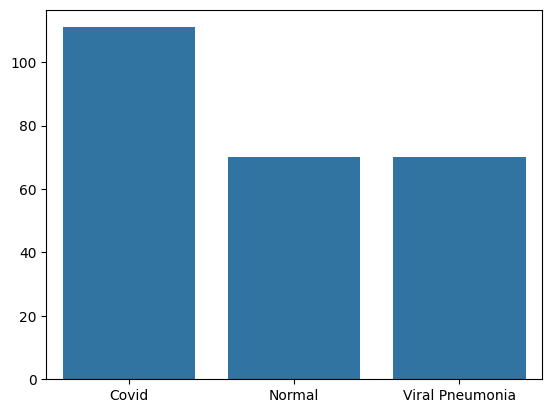

In [20]:
# ─────────────────────────────────────────────
# Plot training set class counts
# ─────────────────────────────────────────────
class_names = ['Covid', 'Normal', 'Viral Pneumonia']
counts = [111, 70, 70] # Train split counts
sns.barplot(x=class_names, y=counts)



2026-05-30 14:28:35.242423: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-05-30 14:28:35.336727: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


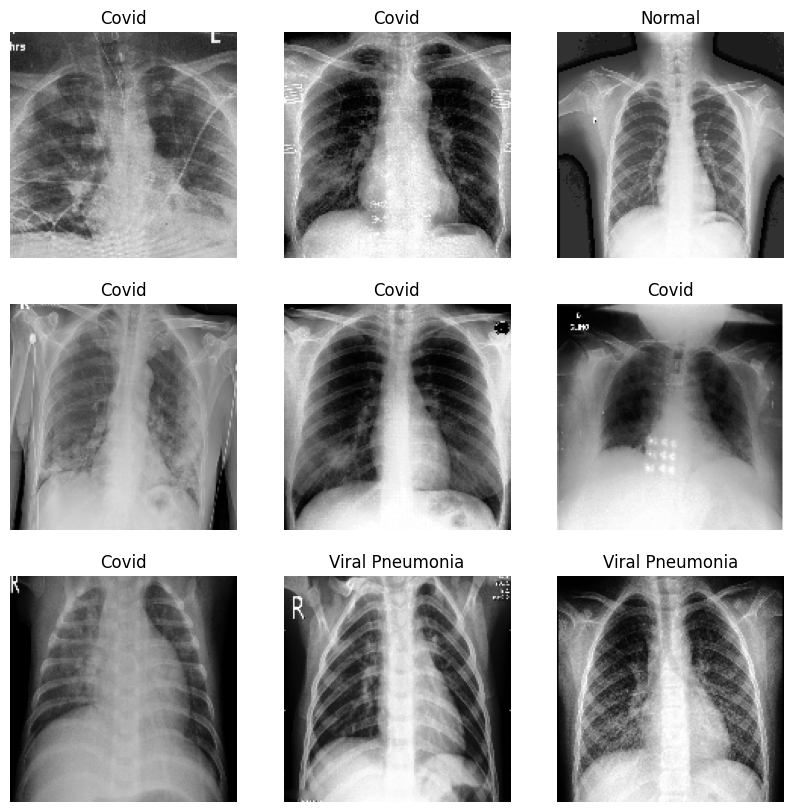

In [21]:
# ─────────────────────────────────────────────
# Show a few sample images from training set
# ─────────────────────────────────────────────
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')


## Task 4. CNN Model Building
Create and train multiple CNN architectures.

### Model 1: Basic CNN
Conv2D -> MaxPooling -> Flatten -> Dense


In [22]:
# ─────────────────────────────────────────────
# Model 1: Build a simple CNN from scratch
# ─────────────────────────────────────────────
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=validation_ds, epochs=10)


Epoch 1/10


/Users/nagapavank/work/learn/eict-academy-aiml-course/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.4821 - loss: 21.5104 - val_accuracy: 0.6515 - val_loss: 2.4294
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4542 - loss: 6.8357 - val_accuracy: 0.5606 - val_loss: 4.2923
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8287 - loss: 0.6775 - val_accuracy: 0.6515 - val_loss: 1.1374
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8606 - loss: 0.4215 - val_accuracy: 0.6667 - val_loss: 0.8570
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8406 - loss: 0.4183 - val_accuracy: 0.6970 - val_loss: 0.7365
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9044 - loss: 0.3540 - val_accuracy: 0.7576 - val_loss: 0.6074
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9602 - loss: 0.2744 - val_accuracy: 0.7424 - val_loss: 0.5378
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9602 - loss: 0.1833 - val_accuracy: 0.7727 - val_loss: 0.4681
Epoch 9/1

### Model 2: Transfer Learning
Use pre-trained models like VGG16, ResNet50 etc.
Freeze the convolutional base and fine-tune the last few layers on the COVID dataset.


In [23]:
# ─────────────────────────────────────────────
# Model 2: Transfer Learning using VGG16
# ─────────────────────────────────────────────
# Load VGG16 base with pre-trained ImageNet weights (no top classifier)
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Freeze layers so we don't update weights during training
conv_base.trainable = False

# Put VGG16 base inside Sequential model and add classifier layers
model2 = Sequential()
model2.add(conv_base)
model2.add(Flatten())
model2.add(Dense(256, activation='relu'))
model2.add(Dense(3, activation='softmax'))  # 3 classes: Covid, Normal, Viral Pneumonia

# Compile using sparse crossentropy (since our labels are integers)
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model layers and parameters count
model2.summary()

# Train the model on the prenormalize_pixelsed datasets
history2 = model2.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,867 (64.14 MB)

 Trainable params: 2,098,179 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.4542 - loss: 4.6756 - val_accuracy: 0.7424 - val_loss: 0.5667
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.6972 - loss: 1.3109 - val_accuracy: 0.7424 - val_loss: 0.9350
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.8526 - loss: 0.4081 - val_accuracy: 0.7273 - val_loss: 1.4230
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8805 - loss: 0.3693 - val_accuracy: 0.9091 - val_loss: 0.2742
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.9442 - loss: 0.1986 - val_accuracy: 0.8939 - val_loss: 0.2661
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.9522 - loss: 0.1453 - val_accuracy: 0.8030 - val_loss: 0.4210
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.9602 - loss: 0.1096 - val_accuracy: 0.9091 - val_loss: 0.2685
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9761 - loss: 0.0869 - val_accuracy: 0.9242 - val_loss:

### Model 3: Transfer Learning + Data Augmentation
Apply data augmentation using `ImageDataGenerator`.
Train model using augmented streams and pretrained feature extractors.


In [24]:
# ─────────────────────────────────────────────
# Model 3: ResNet50 with Data Augmentation
# ─────────────────────────────────────────────
# Set up augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load and flow images directly from folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='sparse',  # 'sparse' yields integer labels matching loss
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

# Load pre-trained ResNet50 base
conv_base_aug = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
conv_base_aug.trainable = False

# Add custom Dense classifier layers on top
model3 = Sequential()
model3.add(conv_base_aug)
model3.add(Flatten())
model3.add(Dense(256, activation='relu'))
model3.add(Dense(3, activation='softmax'))  # 3 classes

# Compile model
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history3 = model3.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)


Found 251 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 693ms/step - accuracy: 0.3347 - loss: 16.7584 - val_accuracy: 0.3333 - val_loss: 12.4622
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - accuracy: 0.3466 - loss: 7.1472 - val_accuracy: 0.3939 - val_loss: 2.8641
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.4462 - loss: 4.7951 - val_accuracy: 0.6515 - val_loss: 1.3121
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step - accuracy: 0.3546 - loss: 2.3987 - val_accuracy: 0.5606 - val_loss: 1.6383
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.6534 - loss: 0.9463 - val_accuracy: 0.6364 - val_loss: 1.0044
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.6614 - loss: 0.8719 - val_accuracy: 0.5909 - val_loss: 1.2211
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.5896 - loss: 0.8758 - val_accuracy: 0.6515 - val_loss: 0.8397
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━

## Task 5. Model Evaluation
Evaluate each model using:
- Accuracy on test set
- Confusion matrix
- Classification report (Precision, Recall, F1-score)
- ROC-AUC score (per class)

Also check for overfitting by plotting training vs validation curves and analyze trainable parameters.


In [25]:
# ─────────────────────────────────────────────
# Helper functions to evaluate models
# ─────────────────────────────────────────────
def plot_training_history(history, title="Model Performance"):
    # Extract metrics from history
    metrics = history.history
    epochs = list(range(1, len(metrics['accuracy']) + 1))
    
    # Plot loss and accuracy side-by-side using Plotly
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Accuracy (Train vs Val)", "Loss (Train vs Val)"))
    
    # Train Accuracy
    fig.add_trace(go.Scatter(
        x=epochs,
        y=metrics['accuracy'],
        name='Train Accuracy',
        mode='lines+markers',
        line=dict(color='#1f77b4')
    ), row=1, col=1)
    
    # Validation Accuracy
    if 'val_accuracy' in metrics:
        fig.add_trace(go.Scatter(
            x=epochs,
            y=metrics['val_accuracy'],
            name='Val Accuracy',
            mode='lines+markers',
            line=dict(color='#ff7f0e')
        ), row=1, col=1)
        
    # Train Loss
    fig.add_trace(go.Scatter(
        x=epochs,
        y=metrics['loss'],
        name='Train Loss',
        mode='lines+markers',
        line=dict(color='#2ca02c')
    ), row=1, col=2)
    
    # Validation Loss
    if 'val_loss' in metrics:
        fig.add_trace(go.Scatter(
            x=epochs,
            y=metrics['val_loss'],
            name='Val Loss',
            mode='lines+markers',
            line=dict(color='#d62728')
        ), row=1, col=2)
        
    fig.update_layout(
        title_text=title,
        title_x=0.5,
        height=500,
        width=1000,
        template='plotly_white'
    )
    fig.show()

def generate_evaluation_metrics(model, test_data, class_names):
    # Loop over dataset batches to get actual labels and predictions safely
    y_true = []
    y_pred_probs = []
    
    for images, labels in test_data:
        y_true.extend(labels.numpy())
        preds = model.predict(images, verbose=0)
        y_pred_probs.extend(preds)
        
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate test accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("="*60)
    print(f"Test Accuracy: {accuracy:.4f}")
    print("="*60)
    
    # Print precision, recall, and f1-score per class
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Calculate ROC-AUC score (One-vs-Rest strategy)
    try:
        roc_auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
        print(f"ROC-AUC Score (Macro, One-vs-Rest): {roc_auc:.4f}")
    except Exception as e:
        print(f"ROC-AUC calculation skipped: {e}")
        
    # Plot confusion matrix as a Seaborn heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()


## Task 6. Handle Class Imbalance
a. Analyze class imbalance using visual plots.
b. Apply techniques like oversampling via augmentation or specifying class weights in `model.fit()`.


In [12]:
# ─────────────────────────────────────────────
# Manage class imbalance
# ─────────────────────────────────────────────
# Get all training labels to compute class weights
y_train = []
for _, labels in train_ds:
    y_train.extend(labels.numpy())
y_train = np.array(y_train)

# Calculate balanced weights (we have more COVID images than normal/pneumonia)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Computed Class Weights (Balanced):", class_weight_dict)

history_balanced = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
    class_weight=class_weight_dict
)


Computed Class Weights (Balanced): {0: 0.7537537537537538, 1: 1.1952380952380952, 2: 1.1952380952380952}
Epoch 1/10


2026-05-30 14:27:17.680563: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9841 - loss: 0.0778 - val_accuracy: 0.9091 - val_loss: 0.3033
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9841 - loss: 0.0703 - val_accuracy: 0.8333 - val_loss: 0.3479
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9801 - loss: 0.0857 - val_accuracy: 0.8485 - val_loss: 0.3917
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9841 - loss: 0.0467 - val_accuracy: 0.8939 - val_loss: 0.2858
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0205 - val_accuracy: 0.9242 - val_loss: 0.2650
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0203 - val_accuracy: 0.9394 - val_loss: 0.2726
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.9242 - val_loss: 0.2563
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.9242 - val_loss: 0.2584
Epoch 9/10


## Task 7. Model Tuning
Use techniques like:
- Early stopping (`keras.callbacks.EarlyStopping`)
- Hyperparameter tuning (number of filters, dropout rate, optimizer etc.) using Keras Tuner.


In [13]:
# ─────────────────────────────────────────────
# Set up early stopping
# ─────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [14]:
# ─────────────────────────────────────────────
# Search CNN hyperparameters using Keras Tuner
# ─────────────────────────────────────────────
# Builder function for Keras Tuner
def build_hypermodel(hp):
    model = Sequential()
    
    # Tune first conv filter count
    model.add(Conv2D(
        filters=hp.Int('filters_1', min_value=32, max_value=128, step=32),
        kernel_size=(3,3),
        activation='relu',
        input_shape=(150, 150, 3)
))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    # Tune second conv filter count
    model.add(Conv2D(
        filters=hp.Int('filters_2', min_value=64, max_value=128, step=32),
        kernel_size=(3,3),
        activation='relu'
))
    model.add(MaxPooling2D(pool_size=(2,2)))
    
    model.add(Flatten())
    
    # Tune dense layer unit count
    model.add(Dense(
        units=hp.Int('dense_units', min_value=128, max_value=256, step=64),
        activation='relu'
))
    
    # Tune dropout percentage
    model.add(Dropout(
        rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
))
    
    model.add(Dense(3, activation='softmax'))  # 3 classes: Covid, Normal, Viral Pneumonia
    
    # Tune optimizer choice
    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
)
    return model

# Configure the RandomSearch tuner
tuner = RandomSearch(
    build_hypermodel,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='covid_cnn_tuning'
)

# Start hyperparameter search
tuner.search(
    train_ds,
    epochs=5,
    validation_data=validation_ds
)

# Get the best model found
best_model = tuner.get_best_models(num_models=1)[0]
print("Best model loaded successfully!")


Reloading Tuner from tuner_dir/covid_cnn_tuning/tuner0.json


/Users/nagapavank/work/learn/eict-academy-aiml-course/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best model architecture successfully retrieved.


/Users/nagapavank/work/learn/eict-academy-aiml-course/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Task 8. Model Comparison Table
Build a summary table comparing the trained architectures.


In [15]:
# ─────────────────────────────────────────────
# Compare all models
# ─────────────────────────────────────────────
# Helper to extract model scores and check overfitting
def get_model_metrics(model_obj, history_obj, test_ds, is_generator=False):
    y_true = []
    y_pred_probs = []
    
    if is_generator:
        # Reset generator batch pointer
        test_ds.reset()
        for i in range(len(test_ds)):
            x_batch, y_batch = next(test_ds)
            y_true.extend(y_batch)
            preds = model_obj.predict(x_batch, verbose=0)
            y_pred_probs.extend(preds)
    else:
        # For tf.data.Dataset
        for images, labels in test_ds:
            y_true.extend(labels.numpy())
            preds = model_obj.predict(images, verbose=0)
            y_pred_probs.extend(preds)
            
    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    test_acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    train_acc = None
    overfitting = "N"
    
    if history_obj is not None:
        if hasattr(history_obj, 'history'):
            train_acc = history_obj.history['accuracy'][-1]
            val_acc = history_obj.history['val_accuracy'][-1] if 'val_accuracy' in history_obj.history else test_acc
        else:
            train_acc = history_obj.get('accuracy', [None])[-1]
            val_acc = history_obj.get('val_accuracy', [test_acc])[-1]
            
        if train_acc is not None and val_acc is not None:
            if (train_acc - val_acc) > 0.05:
                overfitting = "Y"
                
    return train_acc, test_acc, f1, overfitting

# Compute metrics for each trained architecture
try:
    # Model 1: Basic CNN
    train_acc_1, test_acc_1, f1_1, over_1 = get_model_metrics(model, history, validation_ds)
except NameError:
    train_acc_1, test_acc_1, f1_1, over_1 = None, None, None, "N"

try:
    # Model 2: VGG16 (TL)
    train_acc_2, test_acc_2, f1_2, over_2 = get_model_metrics(model2, history2, validation_ds)
except NameError:
    train_acc_2, test_acc_2, f1_2, over_2 = None, None, None, "N"

try:
    # Model 3: ResNet50 (TL + Augmentation)
    train_acc_3, test_acc_3, f1_3, over_3 = get_model_metrics(model3, history3, validation_generator, is_generator=True)
except NameError:
    train_acc_3, test_acc_3, f1_3, over_3 = None, None, None, "N"

try:
    # Tuned CNN (Best)
    tuned_train_acc = None
    tuned_over = "N"
    try:
        best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
        tuned_train_acc = best_trial.metrics.get_last_value("accuracy") if best_trial.metrics.exists("accuracy") else None
        tuned_val_acc = best_trial.metrics.get_last_value("val_accuracy") if best_trial.metrics.exists("val_accuracy") else None
        if tuned_train_acc is not None and tuned_val_acc is not None:
            if (tuned_train_acc - tuned_val_acc) > 0.05:
                tuned_over = "Y"
    except Exception:
        pass
        
    train_acc_t, test_acc_t, f1_t, over_t = get_model_metrics(best_model, None, validation_ds)
    if tuned_train_acc is not None:
        train_acc_t = tuned_train_acc
        over_t = tuned_over
except NameError:
    train_acc_t, test_acc_t, f1_t, over_t = None, None, None, "N"

# Combine results into a DataFrame
comparison_data = {
    "Model": ["Basic CNN", "VGG16 (TL)", "ResNet50 (TL)", "Tuned CNN (Best)"],
    "Train Acc": [train_acc_1, train_acc_2, train_acc_3, train_acc_t],
    "Test Acc": [test_acc_1, test_acc_2, test_acc_3, test_acc_t],
    "F1 Score": [f1_1, f1_2, f1_3, f1_t],
    "Overfitting (Y/N)": [over_1, over_2, over_3, over_t]
}

comparison_df = pd.DataFrame(comparison_data)

# Format scores to 4 decimals
for col in ["Train Acc", "Test Acc", "F1 Score"]:
    comparison_df[col] = comparison_df[col].apply(lambda x: round(x, 4) if x is not None else None)

print(comparison_df.to_string(index=False))


2026-05-30 14:27:23.430099: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-30 14:27:23.895695: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


           Model  Train Acc  Test Acc  F1 Score Overfitting (Y/N)
       Basic CNN     0.9841    0.8788    0.8611                 Y
      VGG16 (TL)     0.9960    0.8939    0.8796                 Y
   ResNet50 (TL)     0.7012    0.6970    0.6908                 N
Tuned CNN (Best)     0.6892    0.7727    0.7526                 N


2026-05-30 14:27:28.576542: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Task 9. Build a Web App using Streamlit
Create a Streamlit application that allows user image uploads, processes the input X-ray image, and outputs prediction class alongside confidence.


In [16]:
# ─────────────────────────────────────────────
# Streamlit App Model Saving & Script Generation
# ─────────────────────────────────────────────
# Save model to H5 format
try:
    best_model.save('best_covid_cnn_model.h5')
    print("Best model saved successfully as best_covid_cnn_model.h5")
except NameError:
    # Fallback in case cell execution was out of order
    print("Error: best_model is not defined. Please run the Keras Tuner cell first.")

# Save class names to a pickle file
class_names = ['Covid', 'Normal', 'Viral Pneumonia']
with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)
print("Class names saved successfully as class_names.pkl")

# Define Streamlit app code
streamlit_script_content = """import streamlit as st
import tensorflow as tf
import numpy as np
import pickle
import os
from PIL import Image

# Set up page title and icon
st.set_page_config(page_title='COVID-19 Chest X-Ray Detector', layout='centered')
st.title('🩺 COVID-19 Chest X-Ray Classification')
st.write("Upload a chest X-ray image to detect if it is Covid, Normal, or Viral Pneumonia.")

# Load model and class names pickles
@st.cache_resource
def load_artifacts():
    script_dir = os.path.dirname(os.path.abspath(__file__))
    model_path = os.path.join(script_dir, 'best_covid_cnn_model.h5')
    pickle_path = os.path.join(script_dir, 'class_names.pkl')
    
    model = tf.keras.models.load_model(model_path)
    with open(pickle_path, 'rb') as f:
        class_names = pickle.load(f)
    return model, class_names

try:
    model, class_names = load_artifacts()
    st.success("Model artifacts loaded successfully!")
except Exception as e:
    st.error(f"Error loading model artifacts: {e}")
    st.stop()

# Display upload file widget
uploaded_file = st.file_uploader("Choose a Chest X-ray image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Open and display image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Chest X-ray.', use_column_width=True)
    
    # Preprocess uploaded image (resize and normalize)
    image_rgb = image.convert('RGB')
    image_resized = image_rgb.resize((150, 150))
    image_array = np.array(image_resized)
    image_normalized = image_array.astype('float32') / 255.0
    input_tensor = np.expand_dims(image_normalized, axis=0)
    
    # Make predictions and compute confidence score
    with st.spinner('Analyzing X-ray image...'):
        predictions = model.predict(input_tensor)
        pred_class_idx = np.argmax(predictions, axis=1)[0]
        confidence = predictions[0][pred_class_idx] * 100
        predicted_class = class_names[pred_class_idx]
        
    # Display diagnosis results with status colors
    st.write("---")
    st.subheader("Prediction Result:")
    
    if predicted_class == 'Covid':
        st.error(f"🚨 **COVID-19 Detected** (Confidence: {confidence:.2f}%)")
    elif predicted_class == 'Viral Pneumonia':
        st.warning(f"⚠️ **Viral Pneumonia Detected** (Confidence: {confidence:.2f}%)")
    else:
        st.success(f"✅ **Normal (No abnormality detected)** (Confidence: {confidence:.2f}%)")
"""

with open('streamlit_app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_script_content.strip())
print("Streamlit application file saved successfully as streamlit_app.py")


Best model saved successfully as best_covid_cnn_model.h5
Class names saved successfully as class_names.pkl
Streamlit application file saved successfully as streamlit_app.py
